# 1 ИМПОРТЫ НЕОБХОДИМЫХ БИБЛОТЕК И ЗАГРУЗКА ДАННЫХ

In [4960]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split




In [4961]:
GDP_growth = pd.read_csv("../data/API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_121708.csv", skiprows=4) # will seperate to Zambia and China
exports = pd.read_csv("../data/API_NE.EXP.GNFS.CD_DS2_en_csv_v2_3934.csv", skiprows=4)
FDI_inflows = pd.read_csv("../data/API_BX.KLT.DINV.WD.GD.ZS_DS2_en_csv_v2_115540.csv", skiprows = 4)
exchange_rate = pd.read_csv("../data/API_PA.NUS.FCRF_DS2_en_csv_v2_121619.csv", skiprows=4)
external_debt = pd.read_csv("../data/API_20_DS2_en_csv_v2_39106.csv", skiprows=4)
copper_prices = pd.read_excel("../data/CMO-Historical-Data-Annual.xlsx", sheet_name = "Annual Prices (Nominal)", skiprows=6)
percipitation = pd.read_csv("../data/API_AG.LND.PRCP.MM_DS2_en_csv_v2_7937.csv", skiprows=4)

# 2 ПРЕДОБРАБОТКА ПЕРЕМЕННЫХ

## 2.1 GDP_Zambia // GDP_china

In [4962]:
GDP_growth.tail()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
261,Kosovo,XKX,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.825656,3.406632,4.756801,-5.340275,10.745656,4.278499,4.067627,4.573097,NaN,NaN
262,"Yemen, Rep.",YEM,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-5.071796,0.752448,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,3.844734,6.177931,7.373709,7.939609,6.122798,...,1.157947,1.556784,0.259936,-6.168918,4.858649,2.058137,0.806105,0.534844,NaN,NaN
264,Zambia,ZMB,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,1.361382,-2.490839,3.272393,12.214048,16.647456,...,3.525863,4.034494,1.441306,-2.785055,6.234922,5.211224,5.367943,3.820048,NaN,NaN
265,Zimbabwe,ZWE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,6.316157,1.434471,6.244345,-1.106172,4.910571,...,4.734411,5.009922,-6.332450,-7.816951,8.468017,6.139263,5.350869,1.742395,NaN,NaN


In [4963]:
GDP_Zambia = GDP_growth[GDP_growth["Country Code"] == "ZMB"]
GDP_China = GDP_growth[GDP_growth["Country Name"] == "China"]
GDP_SA = GDP_growth[GDP_growth["Country Name"] == "South Africa"]
GDP_Switz = GDP_growth[GDP_growth["Country Name"] == "Switzerland"]

In [4964]:
GDP_China.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
40,China,CHN,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,-27.27,-5.58,10.3,18.18,16.95,...,6.891266,6.756718,6.068502,2.340188,8.570085,3.134189,5.414843,4.977357,NaN,NaN


In [4965]:
GDP_Switz.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
37,Switzerland,CHE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,8.108672,4.789941,4.879199,5.256351,2.104555,...,1.3628,2.860446,1.141982,-2.141737,5.55962,3.044061,0.683328,1.302333,NaN,NaN


In [4966]:
GDP_SA.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
263,South Africa,ZAF,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,3.844734,6.177931,7.373709,7.939609,6.122798,...,1.157947,1.556784,0.259936,-6.168918,4.858649,2.058137,0.806105,0.534844,NaN,NaN


Exclude Irrelevant columns

In [4967]:
GDP_China.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [4968]:
GDP_Zambia.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)
GDP_China.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)
GDP_SA.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)
GDP_Switz.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


In [4969]:
GDP_Zambia.head()


,Indicator Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
264,GDP growth (annual %),NaN,1.361382,-2.490839,3.272393,12.214048,16.647456,-5.57031,7.919697,1.24833,...,3.7551,3.525863,4.034494,1.441306,-2.785055,6.234922,5.211224,5.367943,3.820048,NaN


In [4970]:
GDP_Zambia = GDP_Zambia.T
GDP_China = GDP_China.T
GDP_SA = GDP_SA.T
GDP_Switz = GDP_Switz.T


In [4971]:
GDP_Zambia.head()

,264
Indicator Name,GDP growth (annual %)
1960,NaN
1961,1.361382
1962,-2.490839
1963,3.272393


In [4972]:
GDP_China.head()

,40
Indicator Name,GDP growth (annual %)
1960,NaN
1961,-27.27
1962,-5.58
1963,10.3


In [4973]:
GDP_SA.head()

,263
Indicator Name,GDP growth (annual %)
1960,NaN
1961,3.844734
1962,6.177931
1963,7.373709


In [4974]:
GDP_Switz.head()

,37
Indicator Name,GDP growth (annual %)
1960,NaN
1961,8.108672
1962,4.789941
1963,4.879199


Make first row headers

In [4975]:
new_header = GDP_Zambia.iloc[0] # grab the first row for the header
GDP_Zambia = GDP_Zambia[1:] # take the data less the header row
GDP_Zambia.columns = new_header
# GDP_Zambia.reset_index(drop = True, inplace=True)
new_header = GDP_China.iloc[0] # grab the first row for the header
GDP_China = GDP_China[1:] # take the data less the header row
GDP_China.columns = new_header

new_header = GDP_SA.iloc[0] # grab the first row for the header
GDP_SA = GDP_SA[1:] # take the data less the header row
GDP_SA.columns = new_header

new_header = GDP_Switz.iloc[0]
GDP_Switz = GDP_Switz[1:]
GDP_Switz.columns = new_header

In [4976]:
GDP_Zambia.head()

Indicator Name,GDP growth (annual %)
1960,NaN
1961,1.361382
1962,-2.490839
1963,3.272393
1964,12.214048


In [4977]:
GDP_SA.head()

Indicator Name,GDP growth (annual %)
1960,NaN
1961,3.844734
1962,6.177931
1963,7.373709
1964,7.939609


In [4978]:
GDP_Switz.head()

Indicator Name,GDP growth (annual %)
1960,NaN
1961,8.108672
1962,4.789941
1963,4.879199
1964,5.256351


In [4979]:
GDP_Zambia.columns

Index(['GDP growth (annual %)'], dtype='object', name='Indicator Name')

In [4980]:
GDP_Zambia.reset_index(inplace=True)
GDP_Zambia.rename({
    'GDP growth (annual %)': 'ZMB GDP growth (annual %)'
}, axis=1, inplace=True)

GDP_China.reset_index(inplace=True)
GDP_China.rename({
    'GDP growth (annual %)': 'CHN GDP growth (annual %)'
}, axis=1, inplace=True)

GDP_SA.reset_index(inplace=True)
GDP_SA.rename({
    'GDP growth (annual %)': 'ZAF GDP growth (annual %)'
}, axis=1, inplace=True)

GDP_Switz.reset_index(inplace=True)
GDP_Switz.rename({
    'GDP growth (annual %)': 'CHE GDP growth (annual %)'
}, axis=1, inplace=True)


In [4981]:
GDP_China.head()

Indicator Name,index,CHN GDP growth (annual %)
0,1960,NaN
1,1961,-27.27
2,1962,-5.58
3,1963,10.3
4,1964,18.18


In [4982]:
GDP_Zambia.head()

Indicator Name,index,ZMB GDP growth (annual %)
0,1960,NaN
1,1961,1.361382
2,1962,-2.490839
3,1963,3.272393
4,1964,12.214048


In [4983]:
GDP_SA.head()

Indicator Name,index,ZAF GDP growth (annual %)
0,1960,NaN
1,1961,3.844734
2,1962,6.177931
3,1963,7.373709
4,1964,7.939609


In [4984]:
GDP_Switz

Indicator Name,index,CHE GDP growth (annual %)
0,1960,NaN
1,1961,8.108672
2,1962,4.789941
3,1963,4.879199
4,1964,5.256351
...,...,...
61,2021,5.55962
62,2022,3.044061
63,2023,0.683328
64,2024,1.302333


## 2.2 Exports

In [4985]:
exports.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.153472e+09,2.241203e+09,2.232927e+09,1.324111e+09,1.945183e+09,2.686049e+09,3.159820e+09,3.582826e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.329367e+11,2.588136e+11,2.455958e+11,2.095170e+11,2.880277e+11,3.334846e+11,3.084462e+11,3.198254e+11,NaN,NaN
2,Afghanistan,AFG,Exports of goods and services (current US$),NE.EXP.GNFS.CD,2.222223e+07,2.444446e+07,26666680.0,6.888892e+07,7.111114e+07,113333340.0,...,NaN,NaN,NaN,2.079571e+09,2.045190e+09,2.664600e+09,2.890630e+09,NaN,NaN,NaN
3,Africa Western and Central,AFW,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.148003e+10,3.244471e+10,3.000118e+10,1.858315e+10,3.138583e+10,4.618152e+10,3.464337e+10,3.179802e+10,NaN,NaN


In [4986]:
exports.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [4987]:
exports = exports[exports["Country Code"]== "ZMB"]

In [4988]:
exports.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


In [4989]:
exports.head()

,Indicator Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
264,Exports of goods and services (current US$),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.403491e+09,9.053912e+09,9.987165e+09,8.073235e+09,8.473998e+09,1.153788e+10,1.172209e+10,1.126453e+10,8.851528e+09,NaN


Transpose the dataset

In [4990]:
exports = exports.T

In [4991]:
new_header = exports.iloc[0] # grab the first row for the header
exports = exports[1:] # take the data less the header row
exports.columns = new_header

In [4992]:
exports = exports.reset_index()

In [4993]:
exports.head()

Indicator Name,index,Exports of goods and services (current US$)
0,1960,NaN
1,1961,NaN
2,1962,NaN
3,1963,NaN
4,1964,NaN


In [4994]:
exports.head()

Indicator Name,index,Exports of goods and services (current US$)
0,1960,NaN
1,1961,NaN
2,1962,NaN
3,1963,NaN
4,1964,NaN


## 2.3 FDI inflows

In [4995]:
FDI_inflows.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,5.253375,4.399817,-2.247834,6.517186,4.635530,7.465334,-3.584591,2.420512,NaN,NaN
1,Africa Eastern and Southern,AFE,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.040986,1.297499,1.482074,1.421273,4.912515,1.717865,1.961870,2.158144,NaN,NaN
2,Afghanistan,AFG,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.274797,0.661572,0.124496,0.064994,0.144467,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.556357,1.913953,1.227000,1.040844,1.601417,1.468146,2.081636,2.398404,NaN,NaN
4,Angola,AGO,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,-8.766964,-7.212462,-5.076494,-3.171436,-5.474034,-5.028993,-1.977864,-1.098688,NaN,NaN


In [4996]:
FDI_inflows.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [4997]:
FDI_inflows = FDI_inflows[FDI_inflows['Country Code'] == "ZMB"]


In [4998]:
FDI_inflows.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


In [4999]:
FDI_inflows = FDI_inflows.T


In [5000]:
new_header = FDI_inflows.iloc[0] # grab the first row for the header
FDI_inflows = FDI_inflows[1:] # take the data less the header row
FDI_inflows.columns = new_header

In [5001]:
FDI_inflows.reset_index(inplace=True)

In [5002]:
FDI_inflows.tail()

Indicator Name,index,"Foreign direct investment, net inflows (% of GDP)"
61,2021,1.784078
62,2022,-0.223287
63,2023,2.324653
64,2024,9.324378
65,2025,NaN


## 2.4 EXCHANGE RATE

In [5003]:
exchange_rate = exchange_rate[exchange_rate["Country Code"] == "ZMB"]

In [5004]:
exchange_rate.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


In [5005]:
exchange_rate = exchange_rate.T

In [5006]:
new_header = exchange_rate.iloc[0]
exchange_rate = exchange_rate[1:]
exchange_rate.columns = new_header

In [5007]:
exchange_rate.head()

Indicator Name,"Official exchange rate (LCU per US$, period average)"
1960,0.714286
1961,0.714286
1962,0.714286
1963,0.714286
1964,0.714286


In [5008]:
exchange_rate.reset_index(inplace=True)

In [5009]:
exchange_rate.head()

Indicator Name,index,"Official exchange rate (LCU per US$, period average)"
0,1960,0.714286
1,1961,0.714286
2,1962,0.714286
3,1963,0.714286
4,1964,0.714286


## 2.5 ВНЕШНИЙ ДОЛГ

In [5010]:
external_debt[(external_debt["Indicator Name"] == "External debt stocks (% of GNI)") & (external_debt["Country Code"] == "ZMB") ]

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
16155,Zambia,ZMB,External debt stocks (% of GNI),DT.DOD.DECT.GN.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,96.006154,95.025133,128.346607,167.518099,133.551637,103.673946,110.675742,114.201909,NaN,NaN


In [5011]:
external_debt = external_debt[(external_debt["Indicator Name"] == "External debt stocks (% of GNI)") & (external_debt["Country Code"] == "ZMB") ]
external_debt.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)

In [5012]:
external_debt.head(10)

,Indicator Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
16155,External debt stocks (% of GNI),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,77.571432,96.006154,95.025133,128.346607,167.518099,133.551637,103.673946,110.675742,114.201909,NaN


In [5013]:
external_debt = external_debt.T

In [5014]:
new_header = external_debt.iloc[0]
external_debt = external_debt[1:]
external_debt.columns = new_header


In [5015]:
external_debt.reset_index(inplace=True)

In [5016]:
external_debt.head()

Indicator Name,index,External debt stocks (% of GNI)
0,1960,NaN
1,1961,NaN
2,1962,NaN
3,1963,NaN
4,1964,NaN


## 2.6 Copper prices

In [5017]:
copper_prices.columns

Index(['Unnamed: 0', 'Crude oil, average', 'Crude oil, Brent',
       'Crude oil, Dubai', 'Crude oil, WTI', 'Coal, Australian',
       'Coal, South African', 'Natural gas, US', 'Natural gas, Europe',
       'Liquefied natural gas, Japan', 'Natural gas index', 'Cocoa',
       'Coffee, Arabica', 'Coffee, Robusta', 'Tea, avg 3 auctions',
       'Tea, Colombo', 'Tea, Kolkata', 'Tea, Mombasa', 'Coconut oil',
       'Groundnuts', 'Fish meal', 'Groundnut oil', 'Palm oil',
       'Palm kernel oil', 'Soybeans', 'Soybean oil', 'Soybean meal', 'Barley',
       'Maize', 'Sorghum', 'Rice, Thai 5% ', 'Rice, Thai 25% ',
       'Rice, Thai A.1', 'Rice, Viet Namese 5%', 'Wheat, US SRW',
       'Wheat, US HRW', 'Banana, Europe', 'Banana, US', 'Orange', 'Beef',
       'Chicken', 'Lamb **', 'Shrimps, Mexican', 'Sugar, EU', 'Sugar, US',
       'Sugar, world', 'Tobacco, US import u.v.', 'Logs, Cameroon',
       'Logs, Malaysian', 'Sawnwood, Cameroon', 'Sawnwood, Malaysian',
       'Plywood', 'Cotton, A Inde

In [5018]:
copper_prices.rename({
    'Unnamed: 0':'Year',
    'Copper': 'Copper ($/mt)'
}, axis=1, inplace=True) # axis = 1 so pandas knows we're renaming cols

In [5019]:
copper_prices.head()

,Year,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,Aluminum,"Iron ore, cfr spot",Copper ($/mt),Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver
0,NaN,($/bbl),($/bbl),($/bbl),($/bbl),($/mt),($/mt),($/mmbtu),($/mmbtu),($/mmbtu),...,($/mt),($/dmtu),($/mt),($/mt),($/mt),($/mt),($/mt),($/troy oz),($/troy oz),($/troy oz)
1,1960.0,1.63,1.63,1.63,…,…,…,0.14,0.404774,…,...,511.471832,11.42,678.755833,198.85,2196.733333,1631,246.191667,35.27,83.5,0.9137
2,1961.0,1.57,1.57,1.57,…,…,…,0.15,0.404774,…,...,511.471832,11.02,633.084167,176.975,2449.891667,1711,214.308333,35.25,83.5,0.924442
3,1962.0,1.52,1.52,1.52,…,…,…,0.16,0.404774,…,...,498.060392,11.01,645.143333,155.283333,2471.383333,1761,185.925,35.23,83.5,1.083725
4,1963.0,1.5,1.5,1.5,…,…,…,0.16,0.391351,…,...,498.795265,11.02,645.950833,174.808333,2507.733333,1741.666667,211.508333,35.09,80.930833,1.279108


In [5020]:
copper_prices.dtypes

Year                  float64
Crude oil, average     object
Crude oil, Brent       object
Crude oil, Dubai       object
Crude oil, WTI         object
                       ...   
Nickel                 object
Zinc                   object
Gold                   object
Platinum               object
Silver                 object
Length: 70, dtype: object

Commented out the year filter Because we will need to filter in the combined dataset


In [5021]:
copper_prices = copper_prices[["Year", "Copper ($/mt)"]]
# copper_prices = copper_prices[(copper_prices["Year"] >= 1999) & (copper_prices["Year"] <= 2023)] # use bitwise and/or for series

In [5022]:
copper_prices.head()

,Year,Copper ($/mt)
0,NaN,($/mt)
1,1960.0,678.755833
2,1961.0,633.084167
3,1962.0,645.143333
4,1963.0,645.950833


In [5023]:
copper_prices.reset_index(drop = True, inplace=True)

In [5024]:
copper_prices.head()

,Year,Copper ($/mt)
0,NaN,($/mt)
1,1960.0,678.755833
2,1961.0,633.084167
3,1962.0,645.143333
4,1963.0,645.950833


In [5025]:
copper_prices.rename({
    'Year':'index'
}, axis=1, inplace=True)

## 2. 7 ОСАДКИ

In [5026]:
comparison_temporary = percipitation

In [5027]:
percipitation = percipitation[percipitation["Country Code"] == "ZMB"]
percipitation.columns
percipitation.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)
percipitation = percipitation.T

In [5028]:
new_header = percipitation.iloc[0] 
percipitation = percipitation[1:]
percipitation.columns = new_header

In [5029]:
percipitation.reset_index(inplace=True)

In [5030]:
percipitation.head()

Indicator Name,index,Average precipitation in depth (mm per year)
0,1960,NaN
1,1961,1020.0
2,1962,1020.0
3,1963,1020.0
4,1964,1020.0


In [5031]:
comparison_temporary = comparison_temporary[(comparison_temporary["Country Name"] == "Zambia") | (comparison_temporary["Country Name"] == "India")] 

In [5032]:
comparison_temporary.T

,109,264
Country Name,India,Zambia
Country Code,IND,ZMB
Indicator Name,Average precipitation in depth (mm per year),Average precipitation in depth (mm per year)
Indicator Code,AG.LND.PRCP.MM,AG.LND.PRCP.MM
1960,NaN,NaN
...,...,...
2022,1083.0,1020.0
2023,NaN,NaN
2024,NaN,NaN
2025,NaN,NaN


In [5033]:
comparison_temporary.drop(labels=["Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


# 3 ОБЪЕДИНИЕ ДАННЫЕ

to avoid duplicate columns on merge 
[link](https://stackoverflow.com/questions/72919058/pd-merge-multiple-dataframes-with-same-column-name-on-one-specific-column)




In [5034]:
import functools
dfs = [GDP_Zambia, GDP_Switz, GDP_China, GDP_SA, exports, FDI_inflows,copper_prices, external_debt, percipitation]
for df in dfs:
    df['index'] = df['index'].astype(float)
# loop to convert index column to float to avoid error with pd.merge
df = functools.reduce(lambda left, right: pd.merge(left, right, on='index'), dfs)

In [5035]:
df.to_csv("../data/raw_merged.csv")

In [5036]:
df[df['index'] > 1990].head()

,index,ZMB GDP growth (annual %),CHE GDP growth (annual %),CHN GDP growth (annual %),ZAF GDP growth (annual %),Exports of goods and services (current US$),"Foreign direct investment, net inflows (% of GDP)",Copper ($/mt),External debt stocks (% of GNI),Average precipitation in depth (mm per year)
31,1991.0,-0.036133,-0.915817,9.361702,-1.018245,NaN,1.015753,2338.7825,232.49852,1020.0
32,1992.0,-1.730922,-0.043733,14.299611,-2.137033,NaN,1.413845,2281.1575,233.666931,1020.0
33,1993.0,6.797274,-0.125983,13.929078,1.233558,NaN,9.604383,1913.076667,214.606589,1020.0
34,1994.0,-8.625442,1.269758,13.072709,3.2,1204932092.96489,1.093851,2307.4175,199.05593,1020.0
35,1995.0,2.897669,0.480866,11.032812,3.1,1252536629.79289,2.810624,2935.605833,195.170858,1020.0


# 4 EDA и ПРЕДОБРАБОТКА ДАННЫХ

## 4.1 STUFF STUFF

In [5037]:
df.head()

,index,ZMB GDP growth (annual %),CHE GDP growth (annual %),CHN GDP growth (annual %),ZAF GDP growth (annual %),Exports of goods and services (current US$),"Foreign direct investment, net inflows (% of GDP)",Copper ($/mt),External debt stocks (% of GNI),Average precipitation in depth (mm per year)
0,1960.0,NaN,NaN,NaN,NaN,NaN,NaN,678.755833,NaN,NaN
1,1961.0,1.361382,8.108672,-27.27,3.844734,NaN,NaN,633.084167,NaN,1020.0
2,1962.0,-2.490839,4.789941,-5.58,6.177931,NaN,NaN,645.143333,NaN,1020.0
3,1963.0,3.272393,4.879199,10.3,7.373709,NaN,NaN,645.950833,NaN,1020.0
4,1964.0,12.214048,5.256351,18.18,7.939609,NaN,NaN,969.753333,NaN,1020.0


In [5038]:
df.columns

Index(['index', 'ZMB GDP growth (annual %)', 'CHE GDP growth (annual %)',
       'CHN GDP growth (annual %)', 'ZAF GDP growth (annual %)',
       'Exports of goods and services (current US$)',
       'Foreign direct investment, net inflows (% of GDP)', 'Copper ($/mt)',
       'External debt stocks (% of GNI)',
       'Average precipitation in depth (mm per year)'],
      dtype='str')

In [5039]:
df.rename({
    'index': 'Year',
    'ZMB GDP growth (annual %)': 'GDP',
    'CHE GDP growth (annual %)': 'CHE',
    'CHN GDP growth (annual %)': 'CHN',
    'ZAF GDP growth (annual %)': 'ZAF',
    'Exports of goods and services (current US$)': 'EXP',
    'Foreign direct investment, net inflows (% of GDP)': 'FDI',
    'Copper ($/mt)': 'COP',
    'External debt stocks (% of GNI)': 'DEBT',
    # 'exchange_rate': 'EXR',
    'Average precipitation in depth (mm per year)': 'PRECIP'

}, axis=1, inplace=True)

In [5040]:
df.tail()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
61,2021.0,6.234922,5.55962,8.570085,4.858649,11537884956.040899,1.784078,9317.05,133.551637,1020.0
62,2022.0,5.211224,3.044061,3.134189,2.058137,11722089926.113501,-0.223287,8822.365833,103.673946,1020.0
63,2023.0,5.367943,0.683328,5.414843,0.806105,11264526288.2707,2.324653,8490.290833,110.675742,NaN
64,2024.0,3.820048,1.302333,4.977357,0.534844,8851528097.902889,9.324378,9142.14,114.201909,NaN
65,2025.0,NaN,NaN,NaN,NaN,NaN,NaN,9947.305,NaN,NaN


fix datatypes

In [5041]:
df.dtypes

Year      float64
GDP        object
CHE        object
CHN        object
ZAF        object
EXP        object
FDI        object
COP        object
DEBT       object
PRECIP     object
dtype: object

In [5042]:
for col in df.columns:
    df[col] = df[col].astype(float)

In [5043]:
df.dtypes

Year      float64
GDP       float64
CHE       float64
CHN       float64
ZAF       float64
EXP       float64
FDI       float64
COP       float64
DEBT      float64
PRECIP    float64
dtype: object

filter out unnecessary years

In [5044]:
df = df[(df["Year"] >= 1990) & (df['Year'] <= 2023)]

In [5045]:
df.shape

(34, 10)

In [5046]:
# df['Year'] = df['Year'].astype('string')

## 4.2 DEALING WITH DUPLICATES AND MISSING DATA

In [5047]:
df.loc[df.duplicated(keep=False)]

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP


No duplicates found

In [5048]:
df.isna().sum()/len(df)*100

Year       0.000000
GDP        0.000000
CHE        0.000000
CHN        0.000000
ZAF        0.000000
EXP       11.764706
FDI        0.000000
COP        0.000000
DEBT       0.000000
PRECIP     2.941176
dtype: float64

fill missing values with the mean

In [5049]:
df.fillna(df.mean(), inplace=True)

/home/mofo_iam/school/coursework-sem6/.venv/lib/python3.12/site-packages/IPython/core/displayhook.py:292: UserWarning: Output cache limit (currently 1000 entries) hit.
Flushing oldest 200 entries.
  warn('Output cache limit (currently {sz} entries) hit.\n'


,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
30,1990.0,-0.481072,3.674626,3.941631,-0.317760,5.612185e+09,6.164126,2661.482500,229.538021,1020.0
31,1991.0,-0.036133,-0.915817,9.361702,-1.018245,5.612185e+09,1.015753,2338.782500,232.498520,1020.0
32,1992.0,-1.730922,-0.043733,14.299611,-2.137033,5.612185e+09,1.413845,2281.157500,233.666931,1020.0
33,1993.0,6.797274,-0.125983,13.929078,1.233558,5.612185e+09,9.604383,1913.076667,214.606589,1020.0
34,1994.0,-8.625442,1.269758,13.072709,3.200000,1.204932e+09,1.093851,2307.417500,199.055930,1020.0
35,1995.0,2.897669,0.480866,11.032812,3.100000,1.252537e+09,2.810624,2935.605833,195.170858,1020.0
36,1996.0,6.218546,0.471280,9.976200,4.300000,1.024449e+09,3.533283,2294.856667,208.186286,1020.0
37,1997.0,3.814007,2.261325,9.287647,2.600000,1.177864e+09,4.819570,2276.766667,164.339727,1020.0
38,1998.0,-0.385746,3.029969,7.920792,0.500000,8.709129e+08,5.596790,1654.058333,207.250294,1020.0
39,1999.0,4.650190,1.662701,7.737003,2.400000,8.523383e+08,4.758709,1572.860833,183.714702,1020.0


In [5050]:
df.describe()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
count,34.000000,34.000000,34.000000,34.000000,34.000000,3.400000e+01,34.000000,34.000000,34.000000,34.0
mean,2006.500000,4.241876,1.698452,8.835048,2.025814,5.612185e+09,4.505998,4760.873888,120.310222,1020.0
std,9.958246,3.834984,1.749522,2.904720,2.419408,3.845956e+09,2.519009,2634.093063,74.212090,0.0
min,1990.000000,-8.625442,-2.297375,2.340188,-6.168918,8.523383e+08,-0.223287,1559.477500,17.786826,1020.0
25%,1998.250000,3.071747,0.531482,7.099560,0.894065,1.254151e+09,2.465845,2284.582292,41.990289,1020.0
50%,2006.500000,4.875410,1.727423,8.914913,2.442734,5.612185e+09,4.628971,5008.818042,128.995336,1020.0
75%,2014.750000,6.908049,2.847330,10.128104,3.197761,8.908934e+09,6.086017,6932.759250,179.972514,1020.0
max,2023.000000,10.298223,5.559620,14.299611,5.603806,1.172209e+10,9.604383,9317.050000,233.666931,1020.0


Filter out the years

In [5051]:
df = df[(df["Year"] >= 1990) & (df["Year"] <= 2023)].reset_index(drop=True)

In [5052]:
df.head()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT,PRECIP
0,1990.0,-0.481072,3.674626,3.941631,-0.317760,5.612185e+09,6.164126,2661.482500,229.538021,1020.0
1,1991.0,-0.036133,-0.915817,9.361702,-1.018245,5.612185e+09,1.015753,2338.782500,232.498520,1020.0
2,1992.0,-1.730922,-0.043733,14.299611,-2.137033,5.612185e+09,1.413845,2281.157500,233.666931,1020.0
3,1993.0,6.797274,-0.125983,13.929078,1.233558,5.612185e+09,9.604383,1913.076667,214.606589,1020.0
4,1994.0,-8.625442,1.269758,13.072709,3.200000,1.204932e+09,1.093851,2307.417500,199.055930,1020.0


In [5053]:
df.isna().sum()/len(df)*100

Year      0.0
GDP       0.0
CHE       0.0
CHN       0.0
ZAF       0.0
EXP       0.0
FDI       0.0
COP       0.0
DEBT      0.0
PRECIP    0.0
dtype: float64

## 4.3 CHECK CORRELATION

To avoid [multicolinearity](https://www.geeksforgeeks.org/machine-learning/ml-multiple-linear-regression-using-python/) we check the correlation among the independent variables

In [5054]:
df['Year'] = df['Year'].astype('string') # convert year to string so it doesn't take part in the calculations

<Axes: >

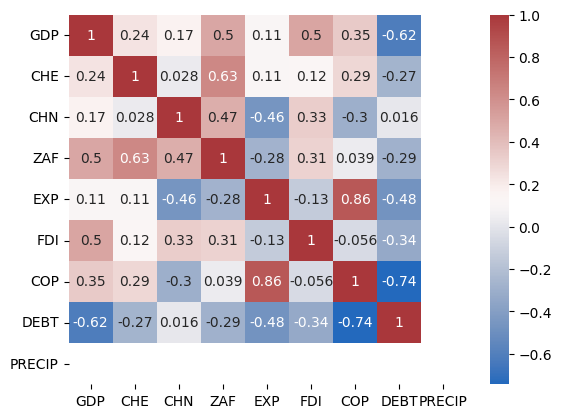

In [5055]:
sns.heatmap(df.corr(numeric_only=True), cmap='vlag', annot=True)

# RANDOM DATA CHECK

In [5056]:
df.drop(labels=['PRECIP', 'Year'], axis=1, inplace=True)

In [5057]:
df.head()

,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT
0,-0.481072,3.674626,3.941631,-0.317760,5.612185e+09,6.164126,2661.482500,229.538021
1,-0.036133,-0.915817,9.361702,-1.018245,5.612185e+09,1.015753,2338.782500,232.498520
2,-1.730922,-0.043733,14.299611,-2.137033,5.612185e+09,1.413845,2281.157500,233.666931
3,6.797274,-0.125983,13.929078,1.233558,5.612185e+09,9.604383,1913.076667,214.606589
4,-8.625442,1.269758,13.072709,3.200000,1.204932e+09,1.093851,2307.417500,199.055930


In [5058]:
# df['Year'] = df['Year'].astype('string')

In [5059]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
scaled = sc.fit_transform(df)
new_df = pd.DataFrame(scaled, columns=df.columns)

In [5060]:
df.dtypes

GDP     float64
CHE     float64
CHN     float64
ZAF     float64
EXP     float64
FDI     float64
COP     float64
DEBT    float64
dtype: object

# 5 ПОСТРОЕНИЕ МОДЕЛЕЙ

## 5.1 ВРУЧНУЮ

## 5.2 С помощью библотек

In [5061]:
df.columns

Index(['GDP', 'CHE', 'CHN', 'ZAF', 'EXP', 'FDI', 'COP', 'DEBT'], dtype='str')

pick dependent and independent variables

In [5062]:
X = new_df[['COP', 'CHN', 'EXP', 'FDI', 'DEBT']]
# , 'FDI', 'CHN', 'CHE', 'ZAF', 'EXP'
# X = new_df[['EXP']]
Y = new_df[['GDP']]

In [5063]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_scaled = scaler.fit_transform(X)
# print(X_scaled)

In [5064]:
X.describe()

,COP,CHN,EXP,FDI,DEBT
count,3.400000e+01,3.400000e+01,3.400000e+01,3.400000e+01,3.400000e+01
mean,1.306145e-17,2.938826e-16,1.306145e-16,-3.036787e-16,-8.408307e-17
std,1.015038e+00,1.015038e+00,1.015038e+00,1.015038e+00,1.015038e+00
min,-1.233647e+00,-2.269593e+00,-1.256236e+00,-1.905673e+00,-1.402267e+00
25%,-9.542302e-01,-6.064566e-01,-1.150188e+00,-8.220826e-01,-1.071224e+00
50%,9.554440e-02,2.790830e-02,0.000000e+00,4.955214e-02,1.187910e-01
75%,8.369283e-01,4.518512e-01,8.700896e-01,6.366711e-01,8.160331e-01
max,1.755706e+00,1.909561e+00,1.612548e+00,2.054402e+00,1.550440e+00


train test split

In [5065]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

Initialize the model

In [5066]:
model = LinearRegression()
model.fit(X_train,Y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


finding intercept and slopes

In [5067]:
print("Intercept: ", model.intercept_)
print("Coefficients: ", model.coef_)

Intercept:  [-0.03755366]
Coefficients:  [[ 0.59561053  0.00545152 -0.44982282  0.52017151 -0.12333311]]


Make predictions

In [5068]:
y_pred = model.predict(X_test)

In [5069]:
from sklearn.metrics import mean_squared_error, r2_score

In [5070]:
print("Mean Squared Error:", mean_squared_error(Y_test, y_pred))
print("R-squared:", r2_score(Y_test, y_pred))

Mean Squared Error: 0.44174327168471866
R-squared: -0.014580237040806798


In [5071]:
result = model.score(X_test, Y_test)
result

-0.014580237040806798

In [5072]:
new_df.shape

(34, 8)

In [5073]:
df.corr()

,GDP,CHE,CHN,ZAF,EXP,FDI,COP,DEBT
GDP,1.000000,0.235134,0.166879,0.499272,0.108563,0.503417,0.345513,-0.616634
CHE,0.235134,1.000000,0.027704,0.633232,0.105891,0.120136,0.291314,-0.267747
CHN,0.166879,0.027704,1.000000,0.465959,-0.461414,0.326563,-0.301257,0.016178
ZAF,0.499272,0.633232,0.465959,1.000000,-0.276637,0.310543,0.038689,-0.285259
EXP,0.108563,0.105891,-0.461414,-0.276637,1.000000,-0.134593,0.855371,-0.475848
FDI,0.503417,0.120136,0.326563,0.310543,-0.134593,1.000000,-0.055833,-0.335164
COP,0.345513,0.291314,-0.301257,0.038689,0.855371,-0.055833,1.000000,-0.744242
DEBT,-0.616634,-0.267747,0.016178,-0.285259,-0.475848,-0.335164,-0.744242,1.000000


Plots

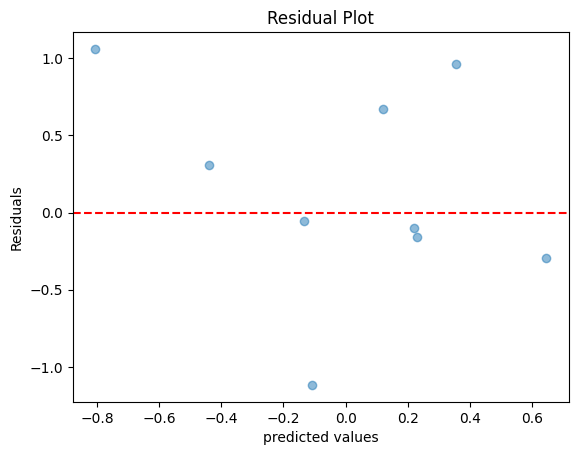

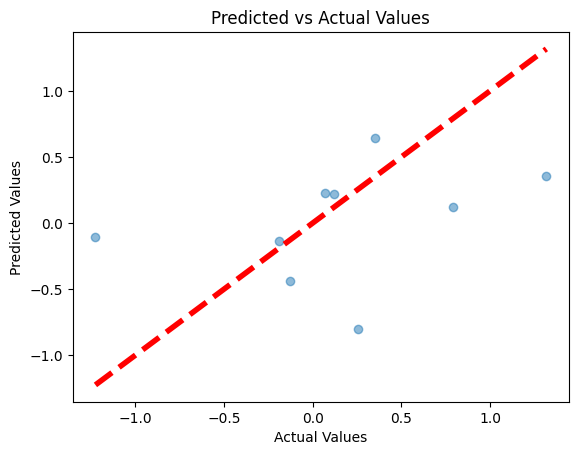

In [5074]:
import matplotlib.pyplot as pp
y_test = Y_test
residuals = y_test - y_pred
pp.scatter(y_pred, residuals, alpha=0.5)
pp.xlabel('predicted values')
pp.ylabel('Residuals')
pp.title('Residual Plot')
pp.axhline(y=0, color='red', linestyle='--')
pp.show()

# Predicted vs Actual Plot
pp.scatter(y_test, y_pred, alpha=0.5)
pp.xlabel('Actual Values')
pp.ylabel('Predicted Values')
pp.title('Predicted vs Actual Values')
pp.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=4)
pp.show()

In [5075]:
# # Source - https://stackoverflow.com/a/68716388
# # Posted by Syed Habeeb Ullah Quadri
# # Retrieved 2026-05-13, License - CC BY-SA 4.0

# import matplotlib.pyplot as plt
# from importlib import reload
# plt=reload(plt)


# y_test = Y_test
# # Residual Plot
# residuals = y_test - y_pred
# plt.scatter(y_pred, residuals, alpha=0.5)
# plt.xlabel('Predicted Values')
# plt.ylabel('Residuals')
# plt.title('Residual Plot')
# plt.axhline(y=0, color='red', linestyle='--')
# plt.show()

# # Predicted vs Actual Plot
# plt.scatter(y_test, y_pred, alpha=0.5)
# plt.xlabel('Actual Values')
# plt.ylabel('Predicted Values')
# plt.title('Predicted vs Actual Values')
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=4)
# plt.show()

# RADNOM STUFF

<Axes: >

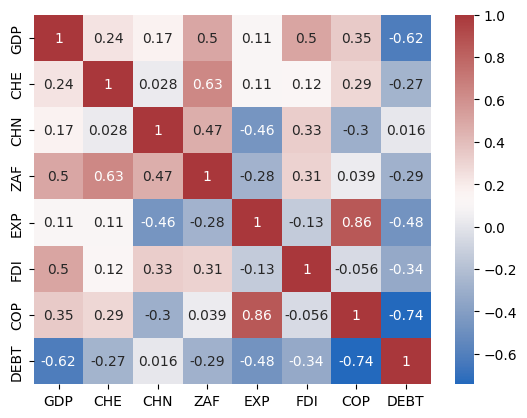

In [5076]:
sns.heatmap(df.corr(numeric_only=True), cmap='vlag', annot=True)